# Volume Optimization for Cubic Systems
**by <span style="color:darkgreen">Pasquale Pavone</span> for [<span style="color:darkgoldenrod">exciting *magnesium*</span>](https://www.exciting-code.org/magnesium)**

<font size="2">(Jupyter notebook by <span style="color:darkgreen">Tejus Rohatgi</span>, <span style="color:darkgreen">Mara Voiculescu</span> & <span style="color:darkgreen">Martin Kuban</span>)</font>
<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**:  In this tutorial you will learn how to set up and execute a series of calculations at different volumes for a cubic crystal. Additionally, it will be explained how to fit the energy-vs-volume curves with either polynomial of various degree or other types of equation of state in order to obtain the corresponding equilibrium volume and bulk modulus.

<div class="alert alert-block alert-warning">
    
**Table of Contents**

[0. Before Starting](#0)
    
[1. Set up the calculations](#1)
 
* [Preparation of the input file](#1-1)  
* [Generation of input files for different volumes](#1-2)

[2. Execute the calculations](#2)
    
[3. Post-processing: Calculating the optimal volume](#3)
  
[4. Additional exercises](#4)
    
</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>

Here is a list of the scripts which are relevant for this tutorial with a short description.

* <code><b>setup.volume_optimization.py</b></code>: Python script for generating structures at different volumes.
* <code><b>execute.volume_optimization.py</b></code>: Python script for running a series of <code><b>exciting</b></code> calculations.
* <code><b>checkfit.energy_vs_volume.py</b></code>: Python script for fitting energy-vs-volume curves.
* <code><b>plot.poly.py</b></code>: Python script for fitting energy-vs-volume curves using a polynomial fit in the volume.
* <code><b>plot.vinet.py</b></code>: Python script for fitting energy-vs-volume curves using the Vinet equation of state.
* <code><b>plot.newbirch.py</b></code>: Python script for fitting energy-vs-volume curves using the Birch-Murnaghan equation of state (<b>BM-EoS</b>) in polynomial form.
* <code><b>plot.birch.py</b></code>: Python script for fitting energy-vs-volume curves using <b>BM-EoS</b>.
* <code><b>plot.pbirch.py</b></code>: Python script for fitting pressure-vs-volume curves using <b>BM-EoS</b>.
* <code><b>plot.bbirch.py</b></code>: Python script for fitting bulk-modulus-vs-volume curves using <b>BM-EoS</b>.

<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Set up the calculations</span>

<a id='1-1'></a>
<b>i) Preparation of the input file</b>

The first step is to create a directory for each system that you want to investigate. In this tutorial, we consider as an example the calculation of the energy-vs-volume curves for silver in the fcc cubic structure. Thus, we will create a directory <b>run_silver_volume_optimization</b>.

In [ ]:
%%bash -l 
mkdir -p run_silver_volume_optimization

Inside this directory, we create (or copy from a previous calculation) the file <b>input.xml</b> corresponding to a <b>SCF</b> calculation at a <span style="color:green"><b>reference lattice constant</b></span> for silver. A possible choice for this reference value is the <span style="color:green"><b>experimental lattice constant</b></span> of <span style="color:red"><b>7.729 Bohr</b></span>. The input file could look like the following.

<span class="SILVER_INPUT"></span>
```xml
<input>
 
   <title>Silver</title>
 
   <structure speciespath="$EXCITINGROOT/species">
 
      <crystal scale="7.729">
         <basevect> 0.5     0.5     0.0 </basevect>
         <basevect> 0.5     0.0     0.5 </basevect>
         <basevect> 0.0     0.5     0.5 </basevect>
      </crystal>
 
      <species speciesfile="Ag.xml">
         <atom coord="0.00 0.00 0.00" />
      </species>
 
   </structure>
 
   <groundstate 
      ngridk="8 8 8"
      swidth="0.01"
      rgkmax="7.5"
      xctype="GGA_PBE_SOL">
   </groundstate>
 
</input>
```

In [ ]:
import os
from excitingjupyter.utilities import get_input_xml_from_notebook

input_str = get_input_xml_from_notebook("volume_optimization_for_cubic_systems", "SILVER_INPUT")

# Write out the input as an XML file:
with open('./run_silver_volume_optimization/input.xml', "w") as fid:
    fid.write(input_str)

Please, remember that the input file for an <code><b>exciting</b></code> calculation must always be called <b>input.xml</b>.

* <span style="color:red; font-weight:bold">N.B. (1)</span>: Do not forget to replace in the <b>input.xml</b> the string "<b><span>&#36;</span>EXCITINGROOT</b>" by the actual value of the environment variable <code><span style="color:mediumblue">$EXCITINGROOT</span></code> using the command

In [ ]:
%%bash -l
cd run_silver_volume_optimization
python3 -m excitingscripts.setup.excitingroot
cd ..

* <span style="color:red; font-weight:bold">N.B. (2)</span>: If the crystal symmetry allows for the relaxation of the position of the atoms in the unit cell, the complete optimization requires the inclusion in the input file of the element  <code><span style="color:mediumblue">relax</span></code> just after the element <code><span style="color:mediumblue">groundstate</span></code> 

```xml
...
   <groundstate 
      ... >
      ...
   </groundstate>
 
   <relax/>
...

```


(for further details, see [<span style="color:firebrick;font-weight:bold">Simple examples of structure optimization</span>]()).

<a id='1-2'></a>
<b>ii) Generation of input files for different volumes</b>

In order to generate input files for a series of volumes you have to run the script <code><b>setup.volume_optimization.py</b></code>. <b>Notice</b> that the script <code><b>setup.volume_optimization.py</b></code> always generates a working directory containing input files for different volumes. Results of the current calculations will be also stored in the working directory. The directory name can be specified by adding the name in the command line.

In [ ]:
%%bash -l
cd run_silver_volume_optimization
python3 -m excitingscripts.setup.volume_optimization -r vol-opt-1 11
cd ..

<span style="color:red; font-weight:bold">Very important</span>: The working directory is overwritten each time you execute the script <code><b>setup.volume_optimization.py</b></code>. Therefore, choose different names for different calculations.

In this example, the working directory is named <b>vol-opt-1</b>. Entry values must be given as arguments. This entry (in our example <span style="color:red;font-weight:bold">11</span>) is the number of structures which are generated with equally spaced intervals of the lattice constant with a variation of between -5% and +5% from the reference lattice constant.

<a id='2'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">2. Execute the calculations</span>

To execute the series of calculations with input files created by <code><b><b>setup.volume_optimization.py</b></code></b></code> you have to run the script <code><b>execute.volume_optimization.py</b></code>. If a name for the working directory has been specified, then you <span style="color:red"><b>must</b></span> give it here, too. Further the number of volume values need to be mentioned as well.

In [ ]:
%%bash -l
cd run_silver_volume_optimization
python3 -m excitingscripts.execute.volume_optimization -r vol-opt-1 11
cd ..

After the complete run, the results of the calculation for the input file are contained in the subdirectory (of the working directory <b>vol-opt-1</b>) <b>volume-i</b> where <b>i</b> is running from <b>1</b> to the total number of volumes. The data for the energy-vs-volume curve are contained in the file <b>energy-vs-volume</b> inside <b>vol-opt-1</b>.

<span style="color:red;font-weight:bold">Hint</span>: You can check the status of the calculations by plotting the energies that have been already obtained while other calculations are still running. In order to do this, open a new terminal window, move inside <b>vol-opt-1</b> and run the script <code><b>plot.energy.py</b></code>

In [ ]:
%%bash -l
cd run_silver_volume_optimization/vol-opt-1
python3 -m excitingscripts.plot.energy
cd ../../

This way, you obtain a <b>PLOT.png</b> file that you can visualize using the standard tools of your operating system. Here is an example:

<figure>
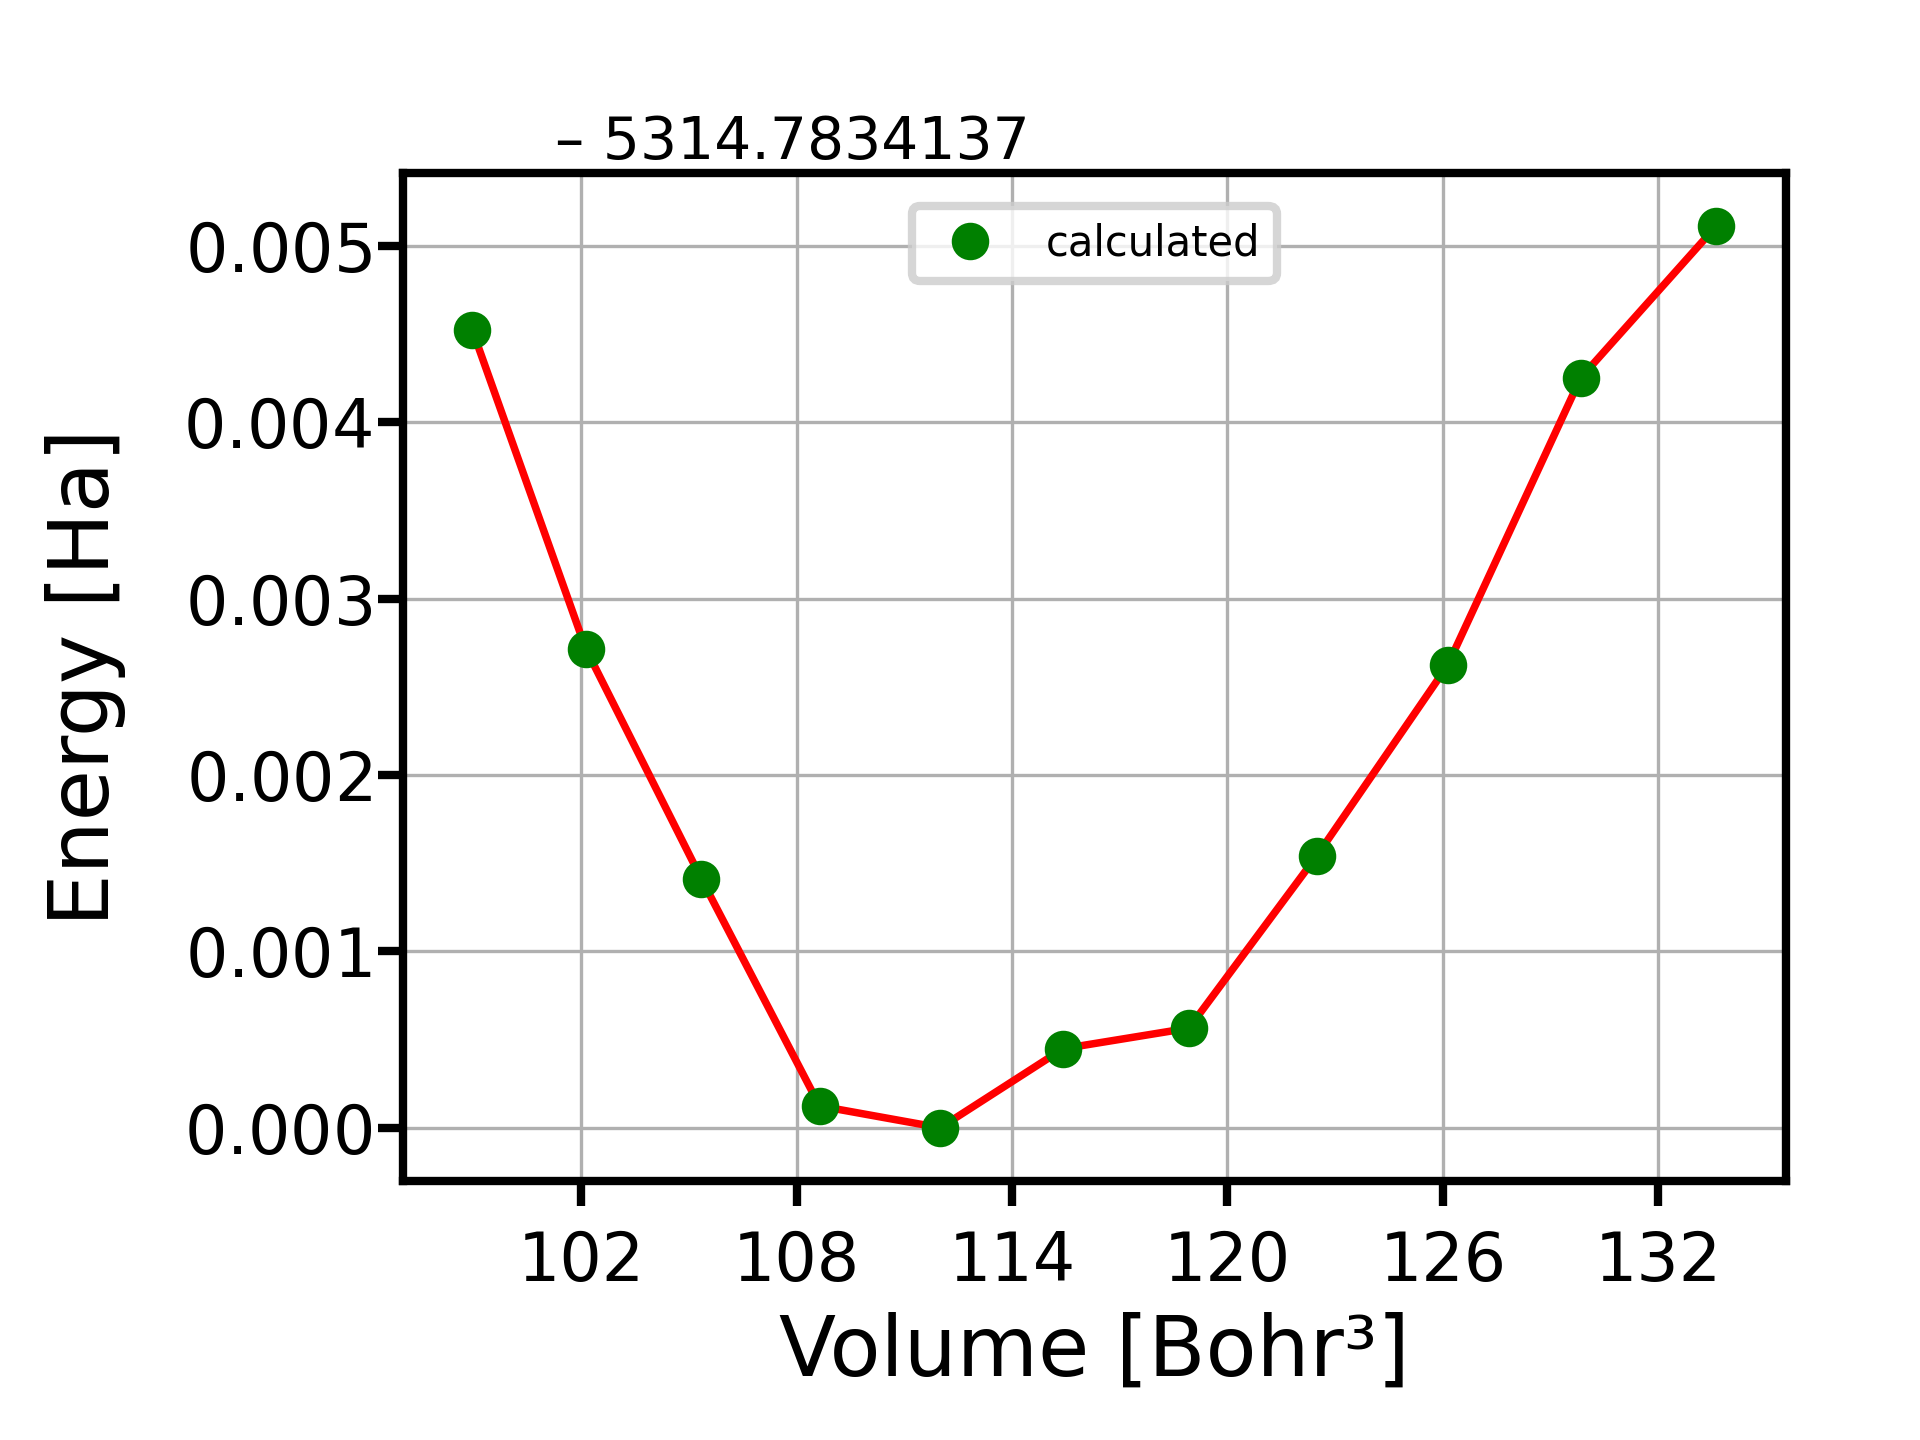
</figure>

<a id='3'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">3. Post-processing: Calculating the optimal volume</span>

In order to analyse the results of the calculations, if you have not done before, you first have to move to the working directory.

At this point, you can use the python script <code><b>checkfit.energy_vs_volume.py</b></code> for performing the polynomial fit and extracting the equilibrium volume and the bulk modulus.

In [ ]:
%%bash -l
cd run_silver_volume_optimization/vol-opt-1
python3 -m excitingscripts.checkfit.energy_vs_volume -o 2 --isym 3 
cd ../..

```
===============================
Lattice symmetry codes
-------------------------------
1 --> Simple cubic (sc)
2 --> Body-centered cubic (bcc)
3 --> Face-centered cubic (fcc)
-------------------------------
0 --> Others
===============================

Verification lattice symmetry code      >>>> 3

##############################################

Optimal volume   =                114.678508 [Bohr^3]
Lattice constant = (fcc)            7.712242 [Bohr]
Bulk modulus     =                104.654586 [GPa]

Log(chi)         =                  -3.39

##############################################

```

Entry values must be given as arguments. The first entry (in our example <span style="color:red;font-weight:bold">-o 2</span>) represents the order of the polynomial for the fit. The second entry (in our example <span style="color:red;font-weight:bold">--isym 3</span>) corresponds to the appropriate choice of the lattice symmetry (face-centered cubic in our example). This enables us to extract the value of the lattice constant and of the bulk modulus as reported in the screen output.

The script generates an output file <b>PLOT.png</b> (Portable Network Graphics), which can be used to visualize the fitting results. An example of the script output is the following.

<figure>
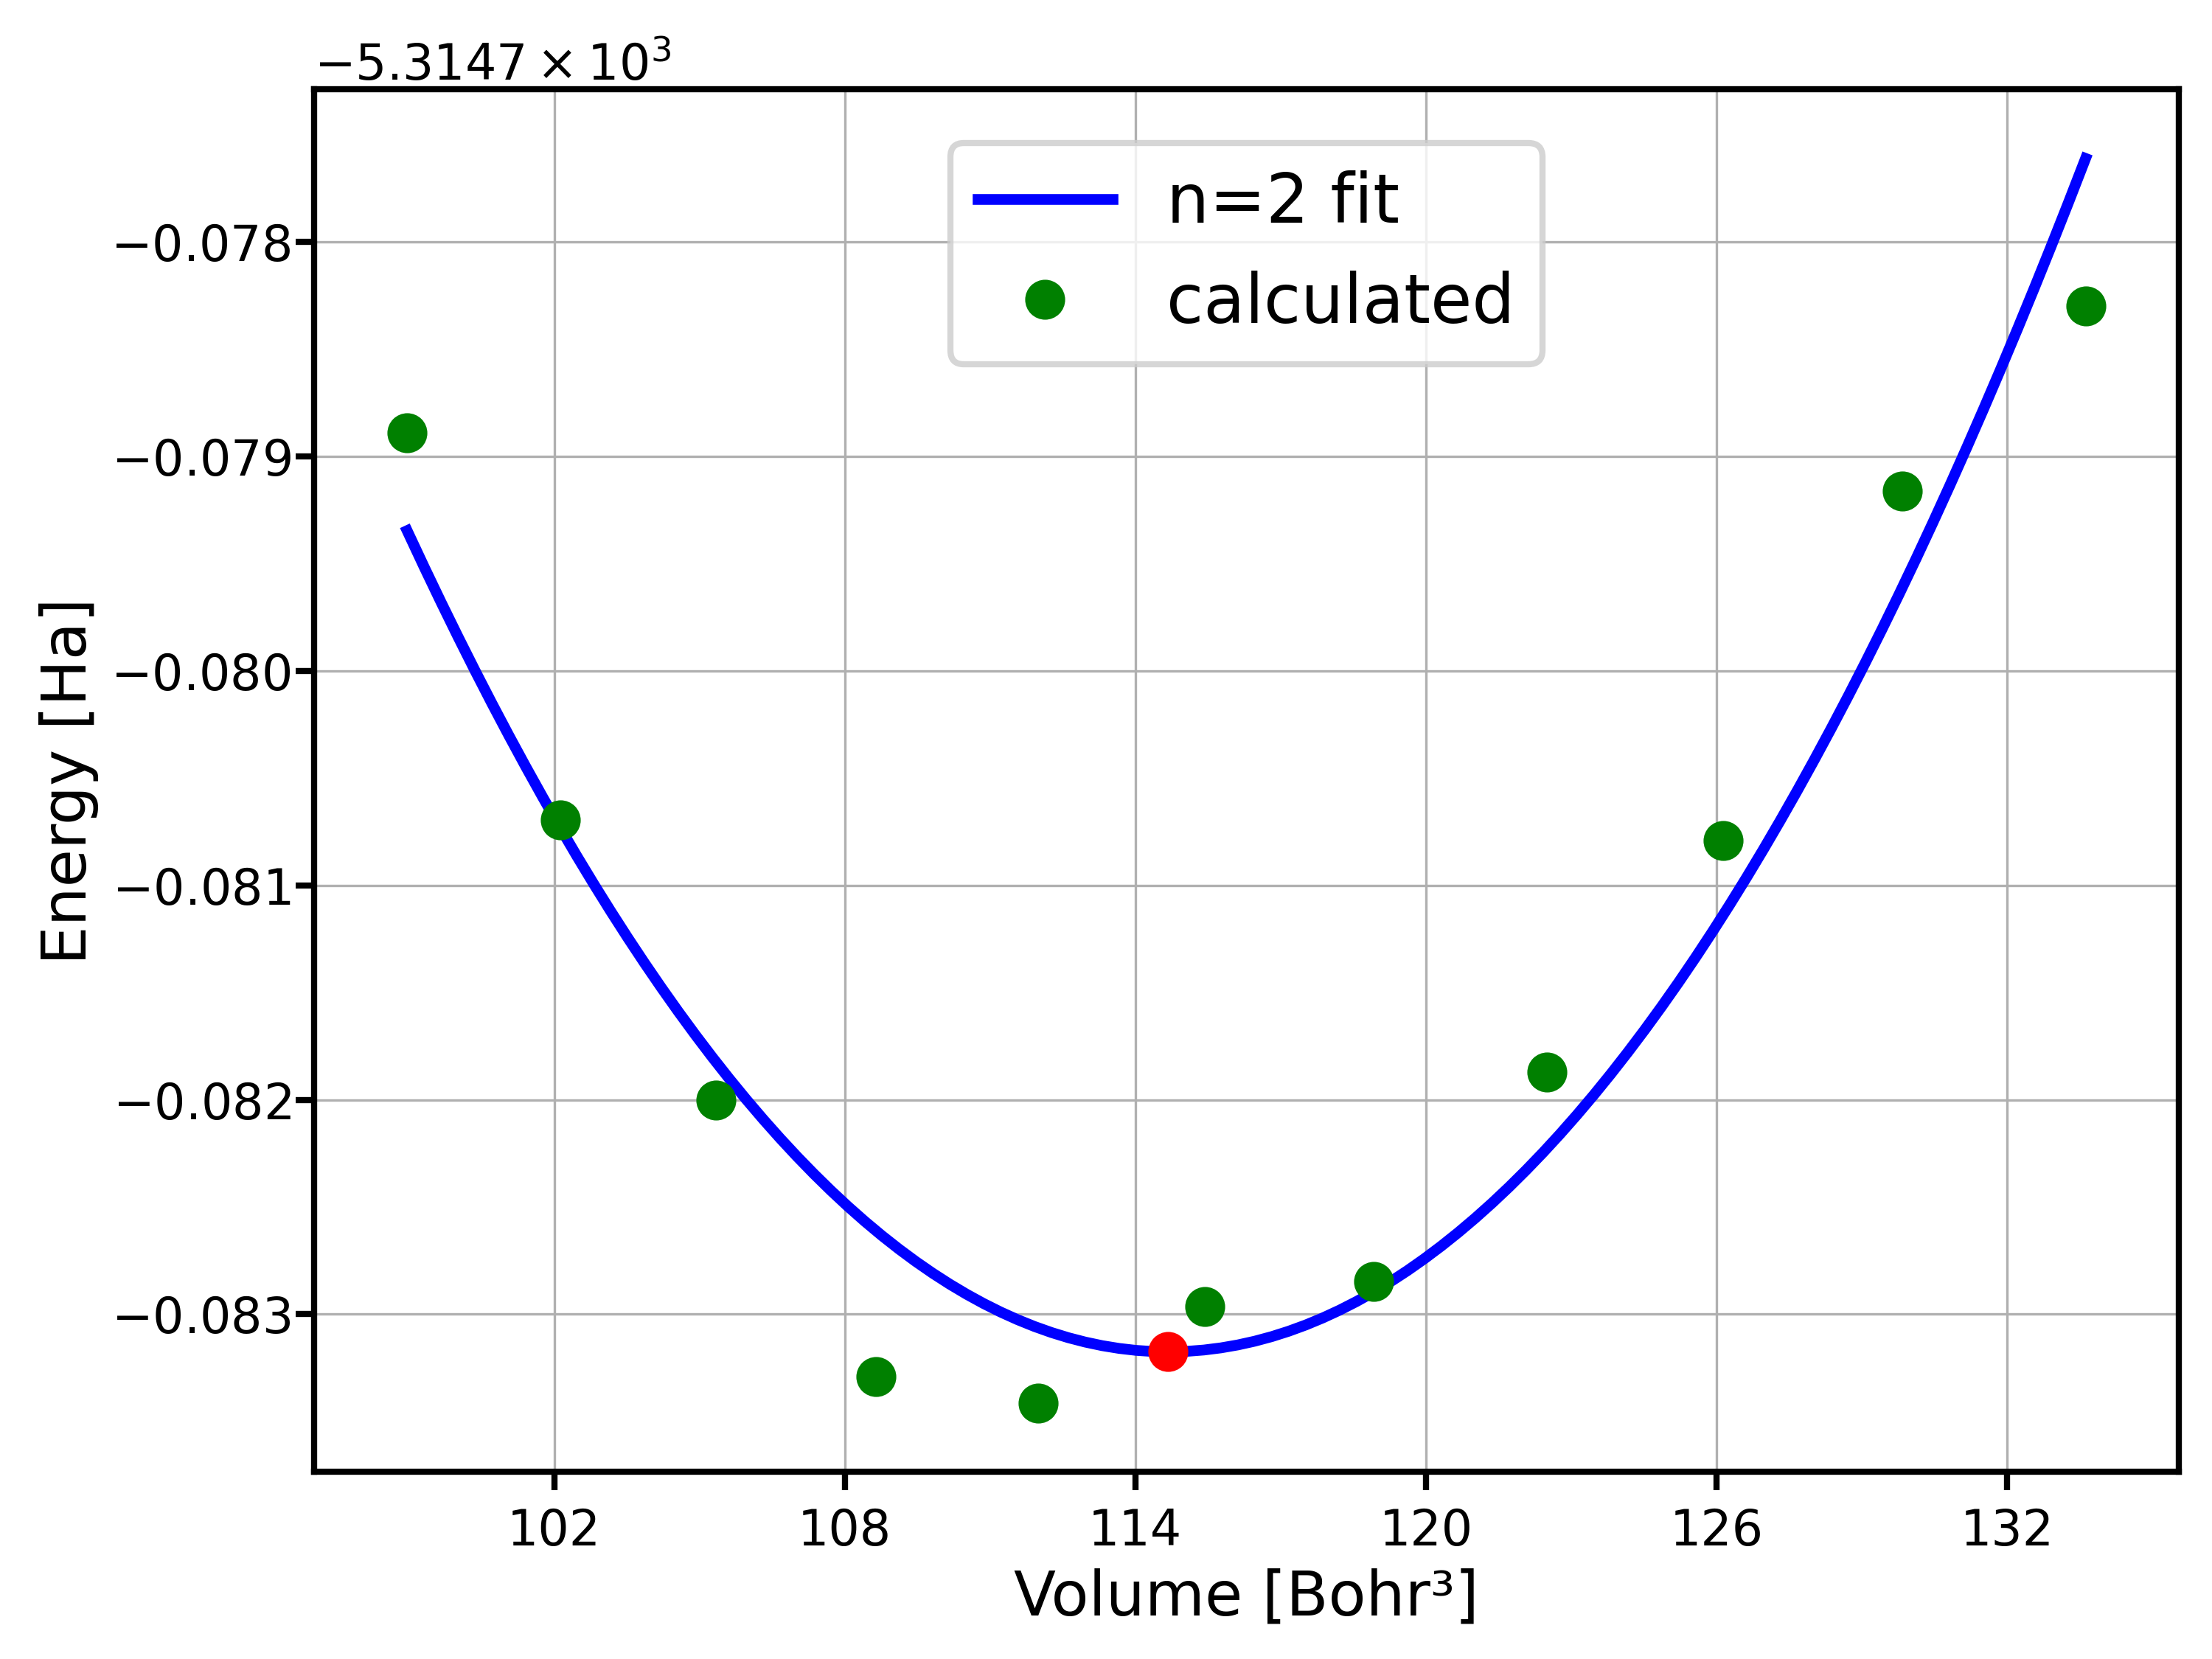
</figure>

<a id='4'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">4. Additional exercises</span>

* Improve the accuracy of the fit by adding more data points.
* If the optimal volume is far from the middle volume in the figure, choose as a new reference lattice constant a value corresponding to the optimal volume.
* Check the accuracy of the calculations by choosing other values for the main computational parameters. An example, corresponding to the choice <code><span style="color:mediumblue">ngridk</span></code> = <b>"12 12 12"</b>, <code><span style="color:mediumblue">rgkmax</span></code> = <b>"8.0"</b>, and using a <span style="color:red;font-weight:bold">4th-order</span> polynomial fit, is the following.

<figure>
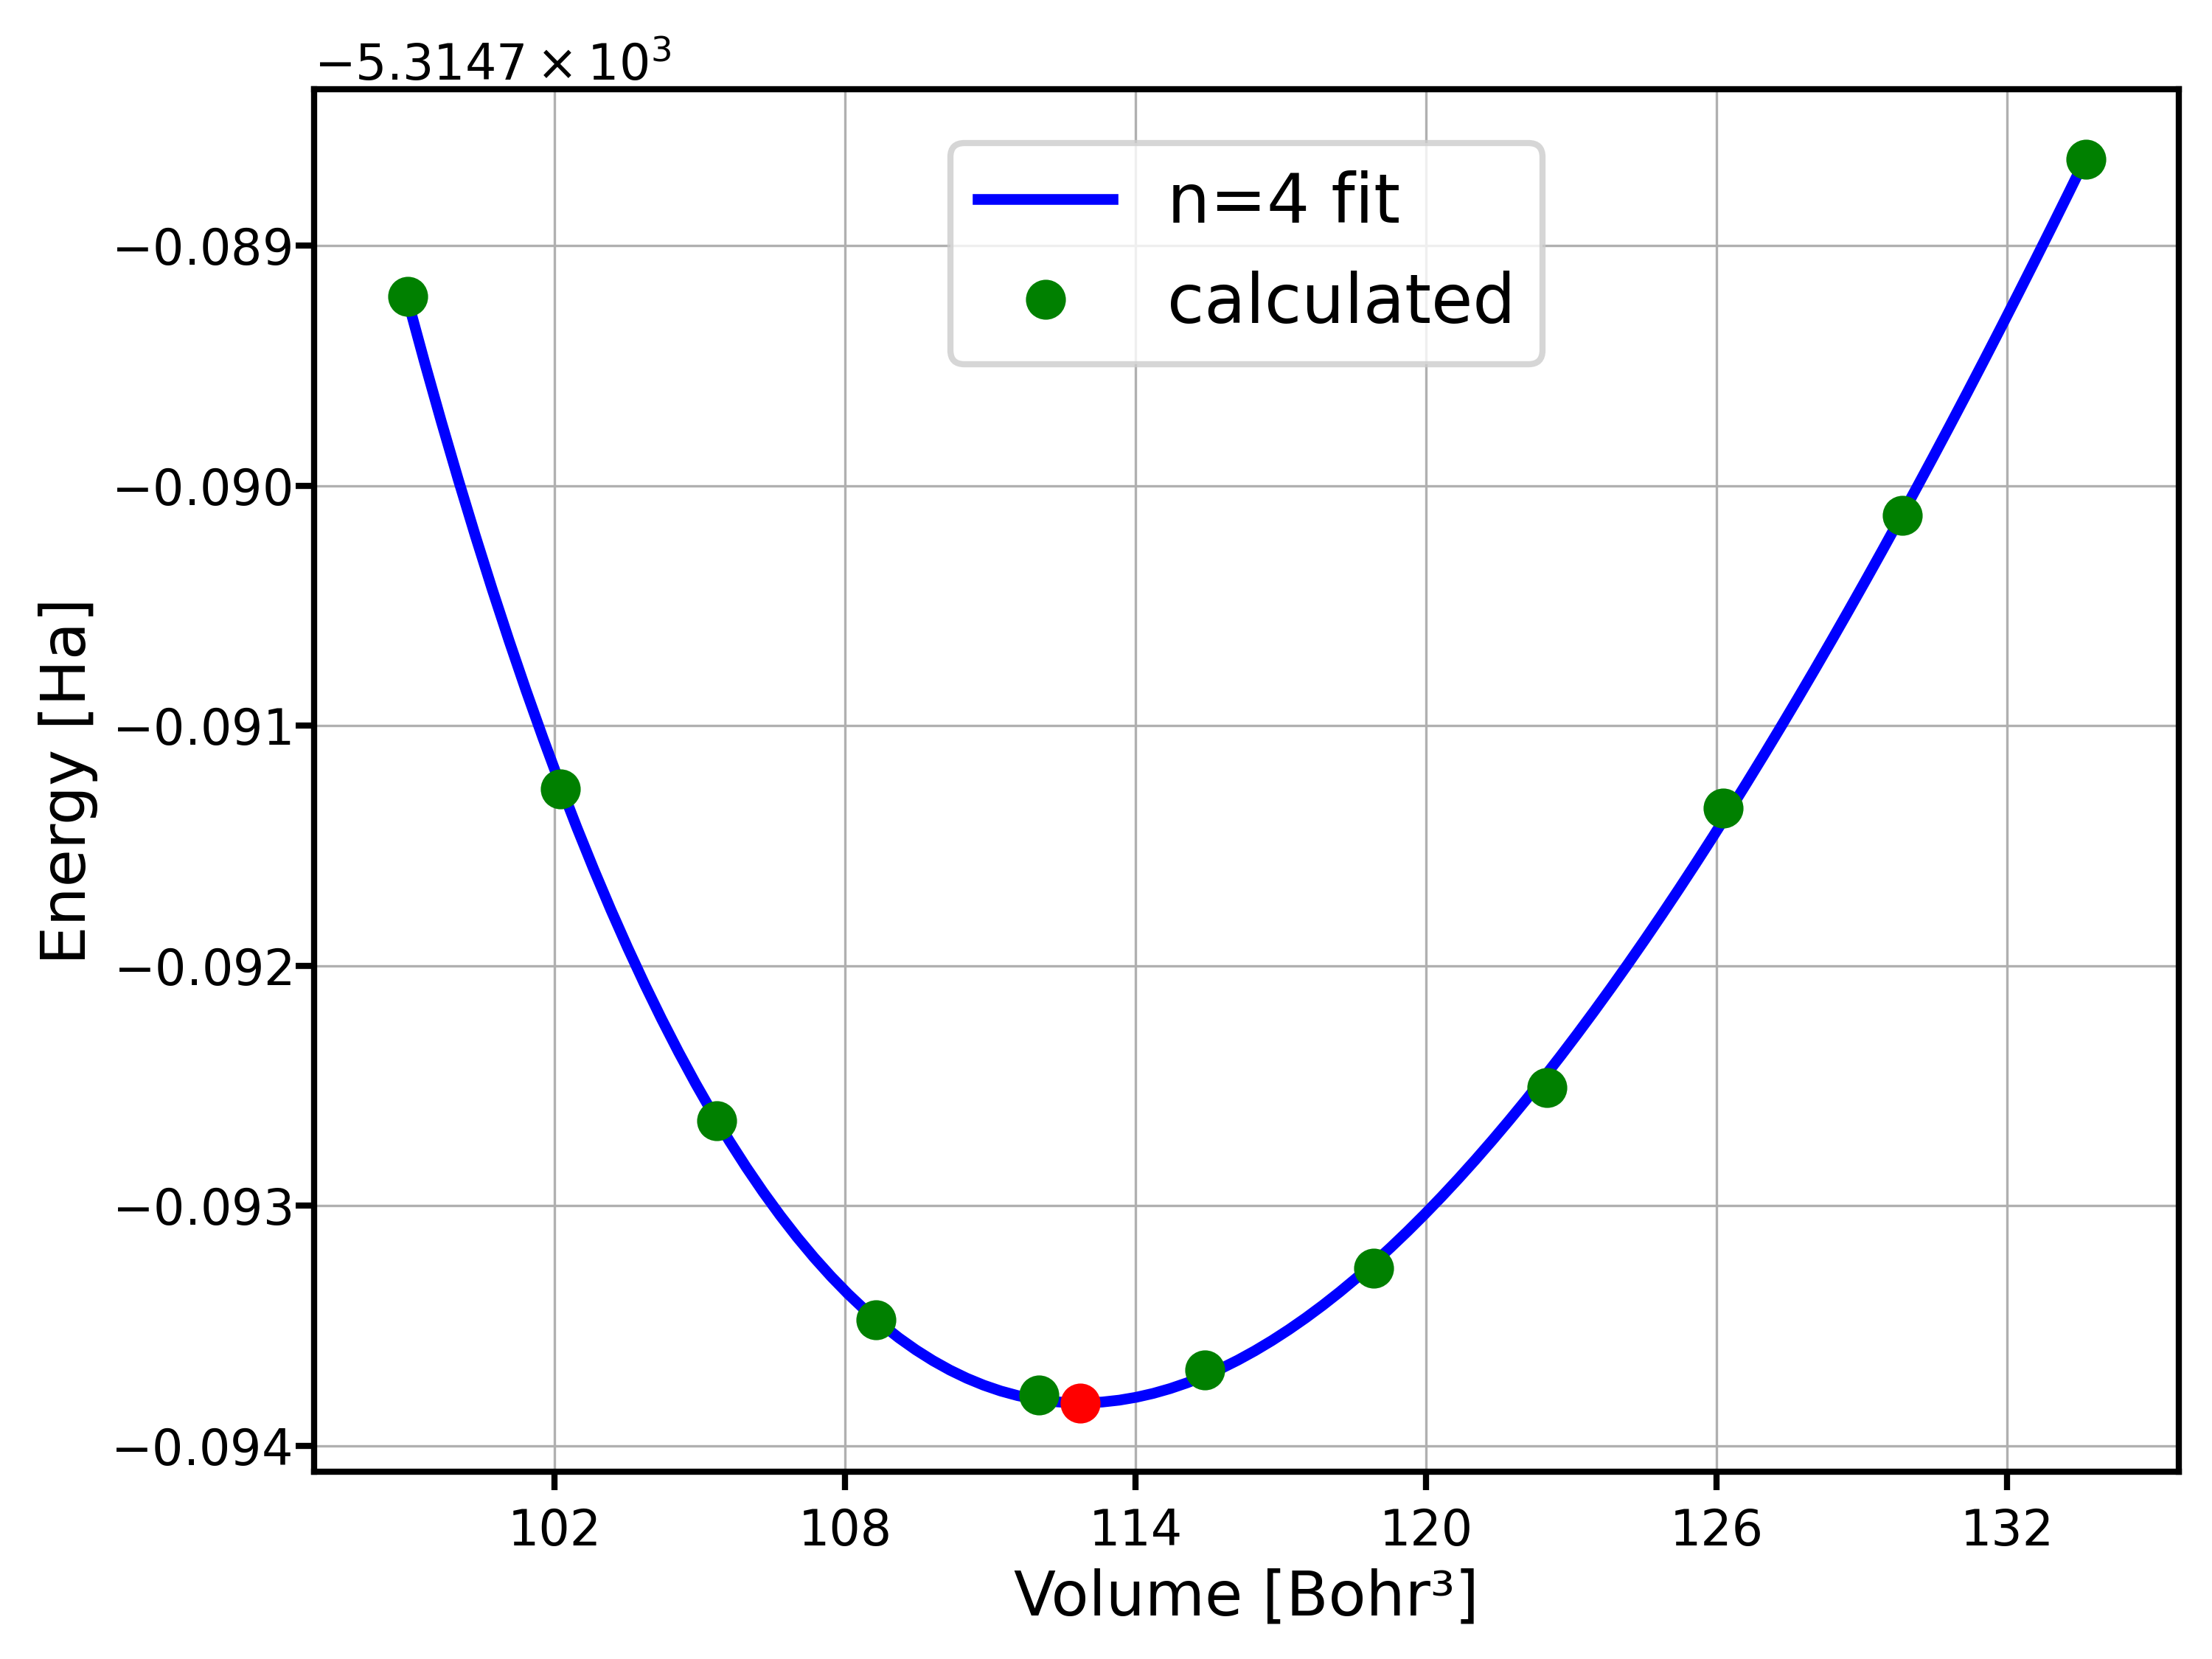
</figure>

* Compare your results with the ones obtained performing a fit using the [<span style="color:firebrick;font-weight:bold">Birch-Murnaghan</span>](https://en.wikipedia.org/wiki/Birch%E2%80%93Murnaghan_equation_of_state) equation of state. In order to do this, use the script <code><b>plot.newbirch.py</b></code>, which can be called in the running directory as:


```bash
python3 -m excitingscripts.plot.newbirch
```

The results should look like this:

```
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
     V0        B0         Bp        a-sc       a-bcc      a-fcc     log(chi)
  112.86526   117.308     5.821     4.8327     6.0888     7.6714      -5.11
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
```

The output on the screen describes the optimal parameters for the fit, as well as a mesure of the quality of the fit <b>log(chi)</b>, lower values of this quantity mean better fit accuracy). The script generates the output file <b>PLOT.png</b>, an example can be found in the following.

<figure>
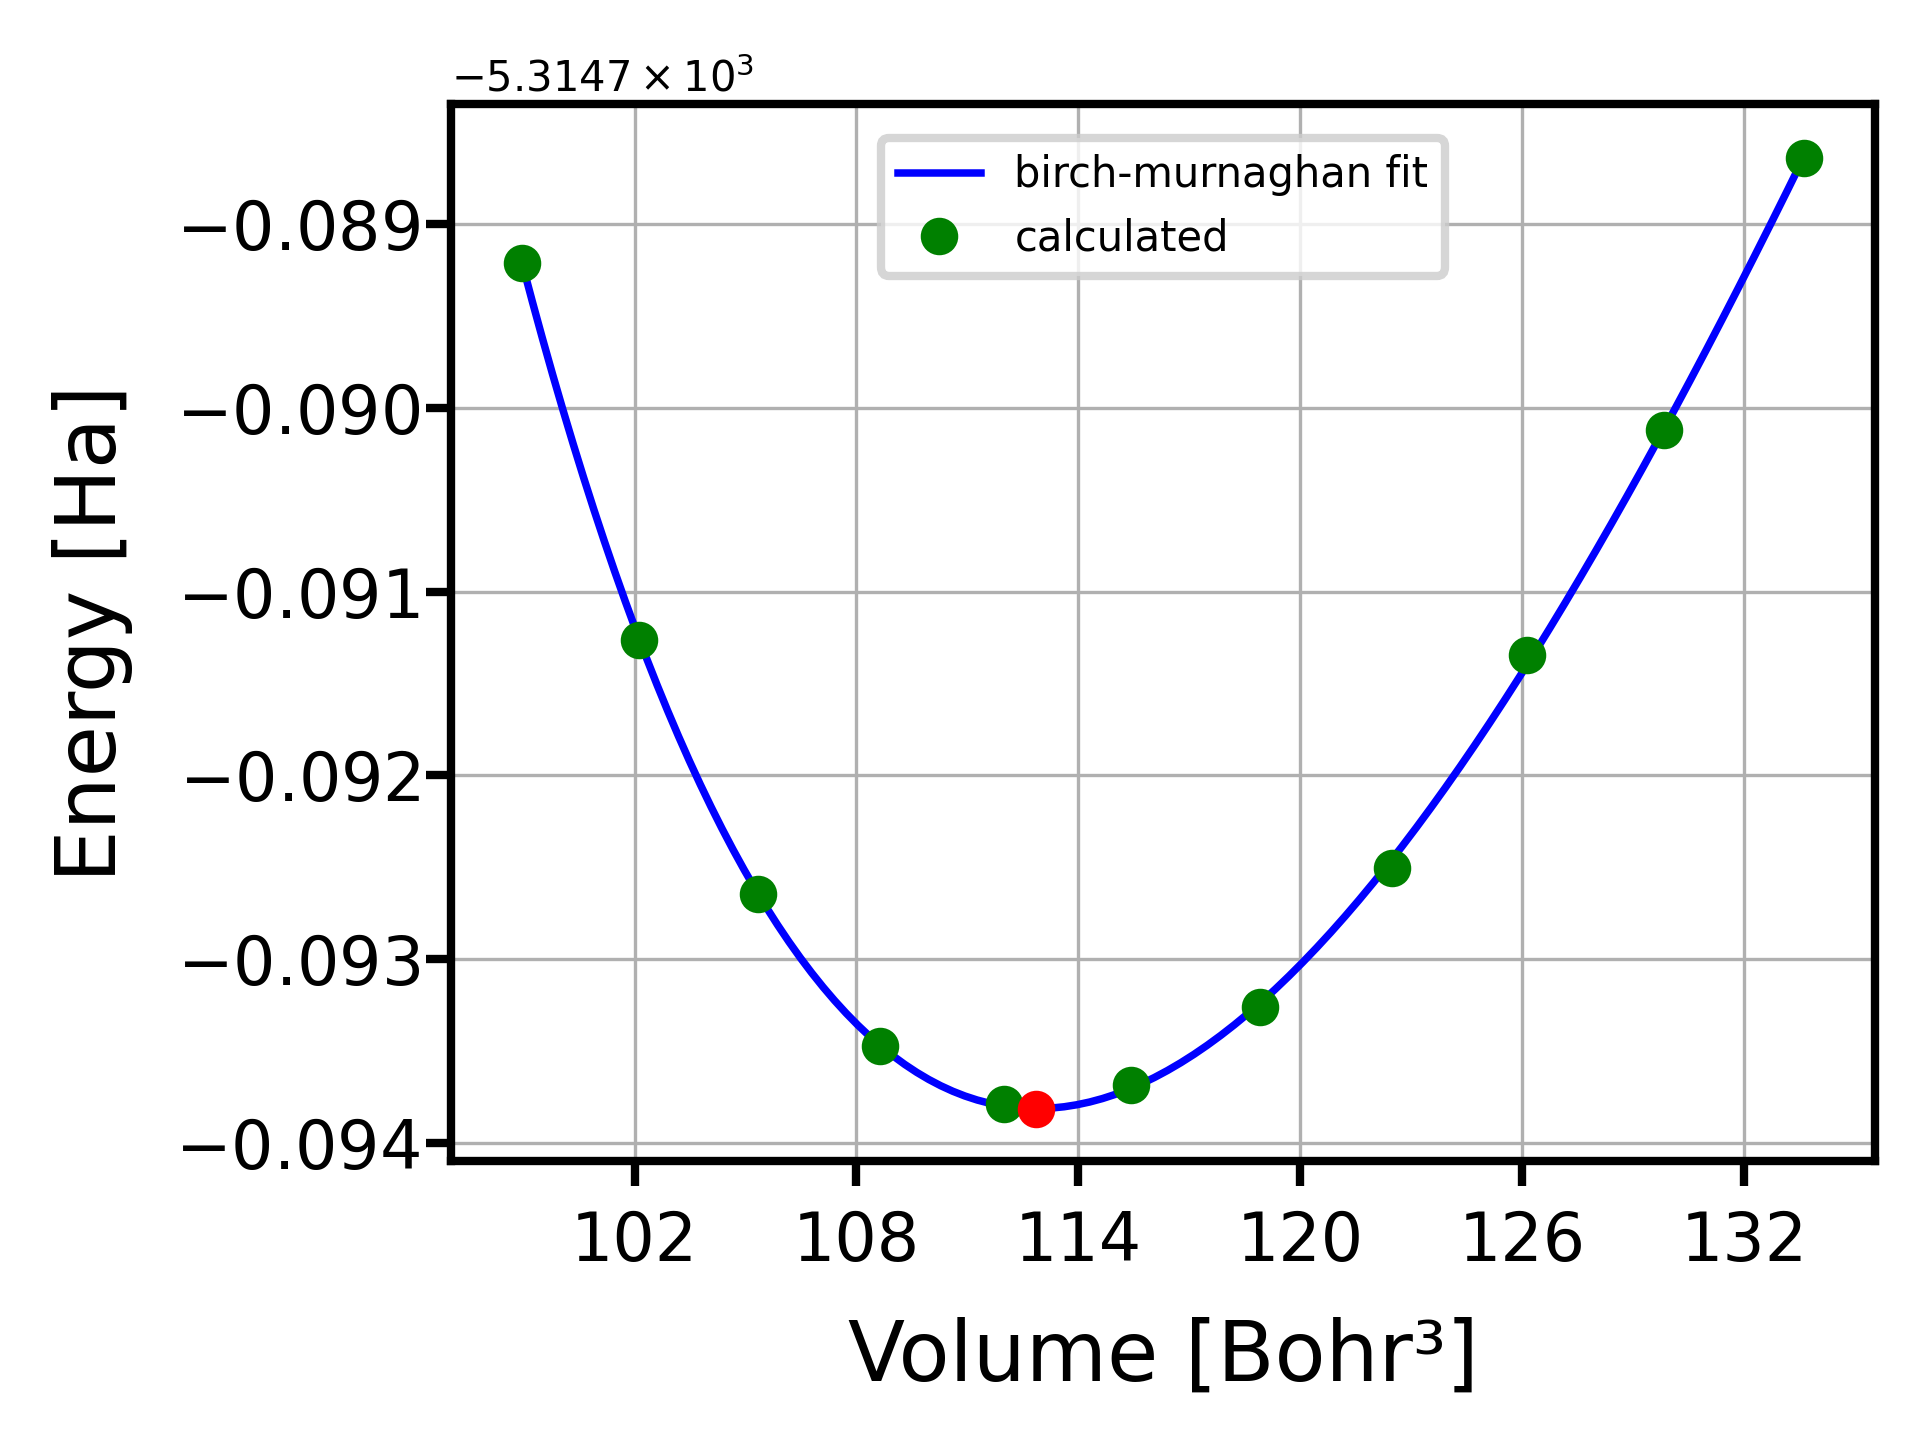
</figure>

* Compare your results with the ones obtained performing a fit using the [<span style="color:firebrick;font-weight:bold">Vinet </span>](https://en.wikipedia.org/wiki/Rose%E2%80%93Vinet_equation_of_state) equation of state.
```bash
python3 -m excitingscripts.plot.vinet
```

* Compare your results with the ones obtained performing a fit using a sixth order polynomial.
```bash
python3 -m excitingscripts.plot.poly -o 6
```

You may also check the effect of using polynomials of different order.
```bash
python3 -m excitingscripts.plot.poly -o 8
```

* Use the script <code><b>plot.pbirch.py</b></code> to visualize the comparison between the pressure calculated using the Birch-Murnaghan equation of state and the one obtained from a finite-differentiation of the calculated energies.
```bash
python3 -m excitingscripts.plot.pbirch
```

* Use the script <code><b>plot.bbirch.py</b></code> to visualize the comparison between the bulk modulus calculated using the Birch-Murnaghan equation of state and a second-order finite-differentiation of the calculated energies.
```bash
python3 -m excitingscripts.plot.bbirch
```

* Choose a new cubic material and repeat all the steps.

<hr style="border:2px solid #DDD"> </hr>